# Laboratorio 8 - SVM para categoria de precios

Este notebook implementa los pasos 1-4 del laboratorio de SVM usando el conjunto `listings.RData`. El objetivo de este avance es dejar lista la base de clasificacion: mismo conjunto de entrenamiento/prueba usado en laboratorios previos, transformaciones necesarias para SVM, variable respuesta categorica de precio y varios modelos SVM con kernels e hiperparametros distintos.

La particion se mantiene reproducible con `test_size=0.2` y `random_state=42`, igual que en el Laboratorio 7.

## Preparacion del entorno

Se importan las librerias necesarias. `pyreadr` permite leer el archivo `.RData`; `scikit-learn` se usa para la particion, el escalado y los modelos SVM.

In [1]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATA_PATH = Path("listings.RData")

if not DATA_PATH.exists():
    raise FileNotFoundError("No se encontro listings.RData en la carpeta del laboratorio.")

print(f"Archivo de datos: {DATA_PATH.resolve()}")

Archivo de datos: /Users/yehosuahercules/Desktop/MineriaDatos/Lab8_MineriaDeDatos/listings.RData


## Carga y revision inicial

Primero se carga el objeto de R y se revisan dimensiones, tipos generales y columnas disponibles. Esta revision sirve para decidir que variables pueden entrar al modelo sin introducir fuga de informacion desde `price`.

In [2]:
resultado = pyreadr.read_r(DATA_PATH)
nombre_objeto = list(resultado.keys())[0]
df_raw = resultado[nombre_objeto]

print(f"Objeto cargado: {nombre_objeto}")
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]:,}")
display(df_raw.head())

display(pd.DataFrame({
    "columna": df_raw.columns,
    "tipo": [str(t) for t in df_raw.dtypes],
    "nulos": df_raw.isna().sum().values,
    "nulos_%": (df_raw.isna().mean().values * 100).round(2),
}).sort_values("nulos_%", ascending=False).head(20))

Objeto cargado: listings
Filas: 171,748 | Columnas: 80


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,"5,456.0000",https://www.airbnb.com/rooms/5456,"20,250,916,040,734.0000",2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,30.2606,-97.7344,Entire guesthouse,Entire home/apt,3,1.0000,1 bath,1,2,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",$97.00,2,90,2,4,90,90,2.1000,90.0000,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550,2009-03-19,2025-09-02,4.8500,4.8800,4.8600,4.9000,4.8200,4.7300,4.7900,NaN,f,1,1,0,0,3.5200,"Austin, Texas"
1,"6,448.0000",https://www.airbnb.com/rooms/6448,"20,250,916,040,734.0000",2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,30.2603,-97.7649,Entire guesthouse,Entire home/apt,2,1.0000,1 bath,1,2,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",$160.00,3,365,3,3,1125,1125,3.0000,"1,125.0000",NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440,2011-09-06,2025-08-20,4.9700,4.9700,4.9600,4.9900,4.9800,4.9700,4.8800,NaN,t,1,1,0,0,1.9800,"Austin, Texas"
2,"8,502.0000",https://www.airbnb.com/rooms/8502,"20,250,916,040,734.0000",2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1,1,"['email', 'phone']",t,f,,78741,NaN,30.2347,-97.7368,Entire guest suite,Entire home/apt,2,1.0000,1 bath,1,1,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",$38.00,

,columna,tipo,nulos,nulos_%
49,calendar_updated,object,171748,100.0000
62,estimated_revenue_l365d,object,95502,55.6100
40,price,str,89381,52.0400
29,neighbourhood_group_cleansed,str,50683,29.5100
71,review_scores_value,float64,40328,23.4800
68,review_scores_checkin,float64,40324,23.4800
70,review_scores_location,float64,40328,23.4800
69,review_scores_communication,float64,40308,23.4700
67,review_scores_cleanliness,float64,40302,23.4700
66,review_scores_accuracy,float64,40312,23.4700


## Transformacion de la variable respuesta

La variable `price` viene como texto con simbolos de moneda. Para usarla en el modelo se limpia a valor numerico y luego se construye `categoria_precio` con tres grupos: `Economica`, `Intermedia` y `Cara`. Se usan los percentiles 33% y 66%, igual que en el laboratorio anterior, para tener clases relativamente balanceadas.

Filas validas despues de limpiar precio: 76,246
Corte Economica <= 141.00
Corte Intermedia <= 264.00
Cara queda por encima del segundo corte


,categoria_precio,conteo,porcentaje
0,Cara,25897,33.9700
1,Economica,25185,33.0300
2,Intermedia,25164,33.0000


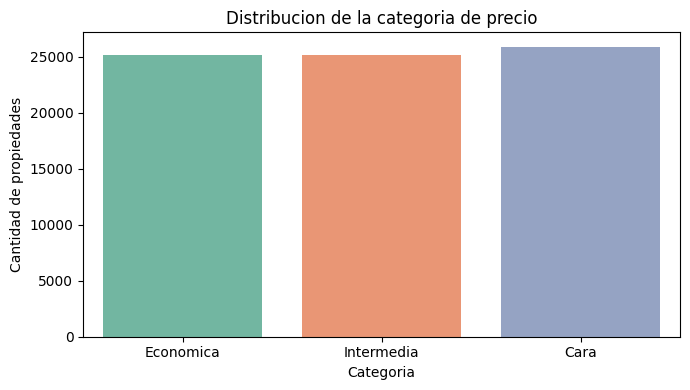

In [3]:
df = df_raw.copy()

# Limpieza de precio: se eliminan simbolos de moneda y separadores que no son numericos.
df["price_num"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[^0-9.\-]", "", regex=True)
)
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")

df_model = df.loc[df["price_num"].notna() & (df["price_num"] > 0)].copy()
p33, p66 = df_model["price_num"].quantile([0.33, 0.66]).values

conditions = [
    df_model["price_num"] <= p33,
    df_model["price_num"] <= p66,
]
choices = ["Economica", "Intermedia"]
df_model["categoria_precio"] = np.select(conditions, choices, default="Cara")

print(f"Filas validas despues de limpiar precio: {len(df_model):,}")
print(f"Corte Economica <= {p33:,.2f}")
print(f"Corte Intermedia <= {p66:,.2f}")
print("Cara queda por encima del segundo corte")

display(
    df_model["categoria_precio"]
    .value_counts()
    .rename_axis("categoria_precio")
    .reset_index(name="conteo")
    .assign(porcentaje=lambda x: (x["conteo"] / x["conteo"].sum() * 100).round(2))
)

plt.figure(figsize=(7, 4))
sns.countplot(data=df_model, x="categoria_precio", order=["Economica", "Intermedia", "Cara"], palette="Set2")
plt.title("Distribucion de la categoria de precio")
plt.xlabel("Categoria")
plt.ylabel("Cantidad de propiedades")
plt.tight_layout()
plt.show()

## Seleccion de predictores y transformaciones para SVM

SVM trabaja con distancias y margenes, por lo que requiere variables numericas comparables. Por eso se aplican estas transformaciones:

- Convertir columnas numericas a `float` y rellenar nulos con la mediana.
- Convertir variables binarias como `instant_bookable` a 0/1.
- Agrupar variables categoricas de alta cardinalidad (`city`, `property_type`) en sus niveles mas frecuentes para evitar demasiadas columnas dummy.
- Crear variables dummy para categoricas como `room_type`, `city_grupo` y `property_type_grupo`.
- Escalar todos los predictores con `StandardScaler`, ajustado solo con entrenamiento.

No se incluye `price_num`, `price` ni variables derivadas directamente de ingresos como `estimated_revenue_l365d`, porque pueden filtrar informacion de la respuesta.

In [4]:
numeric_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "reviews_per_month",
    "calculated_host_listings_count",
]

categorical_features = ["room_type", "city_grupo", "property_type_grupo", "instant_bookable"]

for col in numeric_features:
    if col not in df_model.columns:
        df_model[col] = np.nan
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Agrupacion de categoricas de alta cardinalidad.
for source_col, grouped_col, top_n in [
    ("city", "city_grupo", 12),
    ("property_type", "property_type_grupo", 12),
]:
    if source_col in df_model.columns:
        top_values = df_model[source_col].fillna("Sin dato").value_counts().head(top_n).index
        df_model[grouped_col] = np.where(
            df_model[source_col].fillna("Sin dato").isin(top_values),
            df_model[source_col].fillna("Sin dato"),
            "Otro",
        )
    else:
        df_model[grouped_col] = "Sin dato"

if "room_type" not in df_model.columns:
    df_model["room_type"] = "Sin dato"

if "instant_bookable" in df_model.columns:
    df_model["instant_bookable"] = df_model["instant_bookable"].map({"t": "Si", "f": "No"}).fillna("Sin dato")
else:
    df_model["instant_bookable"] = "Sin dato"

X_num = df_model[numeric_features].copy()
X_num = X_num.fillna(X_num.median(numeric_only=True))

X_cat = pd.get_dummies(
    df_model[categorical_features].fillna("Sin dato").astype(str),
    drop_first=True,
    dtype=float,
)

X = pd.concat([X_num, X_cat], axis=1)
y = df_model["categoria_precio"].copy()

print(f"Predictores finales: {X.shape[1]}")
display(X.head())

Predictores finales: 42


,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,room_type_Hotel room,room_type_Private room,room_type_Shared room,"city_grupo_Boston, Massachusetts","city_grupo_Chicago, Illinois",city_grupo_Hawaii,city_grupo_Rhode Island,"city_grupo_San Diego, California","city_grupo_Washington, D.C.",property_type_grupo_Entire cottage,property_type_grupo_Entire guest suite,property_type_grupo_Entire guesthouse,property_type_grupo_Entire home,property_type_grupo_Entire rental unit,property_type_grupo_Entire serviced apartment,property_type_grupo_Entire townhouse,property_type_grupo_Otro,property_type_grupo_Private room in home,property_type_grupo_Private room in rental unit,property_type_grupo_Private room in resort,property_type_grupo_Room in hotel,instant_bookable_Si
0,3,1.0000,1.0000,2.0000,2,90,13,35,65,328,708,25,1,4.8500,4.8800,4.8600,4.7300,4.7900,3.5200,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2,1.0000,1.0000,2.0000,3,365,12,30,50,316,339,14,1,4.9700,4.9700,4.9600,4.9700,4.8800,1.9800,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,2,1.0000,1.0000,1.0000,4,90,29,59,88,88,54,1,0,4.5700,4.5500,4.6700,4.6900,4.6300,0.2800,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,3,2.0000,2.0000,2.0000,15,150,7,17,47,321,19,1,0,5.0000,4.9500,4.9500,5.0000,4.9500,0.1100,2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,2,1.0000,1.0000,1.0000,30,365,27,40,40,211,56,3,0,4.9500,5.0000,4.9800,4.7200,4.8400,0.3000,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


## Mismo conjunto de entrenamiento y prueba

Para cumplir con la comparacion valida entre laboratorios, se conserva la misma particion usada previamente: 80% entrenamiento, 20% prueba y semilla 42. Se usa `stratify=y` para mantener la proporcion de `Economica`, `Intermedia` y `Cara` en ambos conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_scaled.shape[0]:,} filas")
print(f"Prueba: {X_test_scaled.shape[0]:,} filas")

display(pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True) * 100).round(2),
    "test_%": (y_test.value_counts(normalize=True) * 100).round(2),
}).loc[["Economica", "Intermedia", "Cara"]])

Entrenamiento: 60,996 filas
Prueba: 15,250 filas


,train_%,test_%
categoria_precio,,
Economica,33.0300,33.0300
Intermedia,33.0000,33.0000
Cara,33.9600,33.9700


## Muestra estratificada para entrenar SVM

El conjunto tiene mas de 170 mil registros. `SVC` con kernels no lineales puede crecer mucho en tiempo y memoria porque calcula relaciones entre pares de observaciones. Por eso se mantiene el split completo, pero el entrenamiento inicial de SVM se hace sobre una muestra estratificada fija del conjunto de entrenamiento. Esta decision permite probar varios kernels y parametros en tiempos razonables sin cambiar la definicion de entrenamiento/prueba.

In [6]:
SVM_TRAIN_SIZE = 8000
SVM_TEST_SIZE = 4000

train_sample_idx, _ = train_test_split(
    np.arange(len(y_train)),
    train_size=min(SVM_TRAIN_SIZE, len(y_train)),
    random_state=RANDOM_STATE,
    stratify=y_train,
)

test_sample_idx, _ = train_test_split(
    np.arange(len(y_test)),
    train_size=min(SVM_TEST_SIZE, len(y_test)),
    random_state=RANDOM_STATE,
    stratify=y_test,
)

X_train_svm = X_train_scaled[train_sample_idx]
y_train_svm = y_train.iloc[train_sample_idx].copy()
X_test_svm = X_test_scaled[test_sample_idx]
y_test_svm = y_test.iloc[test_sample_idx].copy()

print(f"Muestra SVM entrenamiento: {X_train_svm.shape[0]:,} filas")
print(f"Muestra SVM prueba: {X_test_svm.shape[0]:,} filas")
display(y_train_svm.value_counts(normalize=True).mul(100).round(2).rename("train_svm_%"))

Muestra SVM entrenamiento: 8,000 filas
Muestra SVM prueba: 4,000 filas


categoria_precio
Cara         33.9600
Economica    33.0400
Intermedia   33.0000
Name: train_svm_%, dtype: float64

## Modelos SVM con kernels y parametros distintos

Se generan cuatro modelos para cubrir mas de dos configuraciones:

- Kernel lineal con `C=0.5`.
- Kernel RBF con `C=1.0` y `gamma='scale'`.
- Kernel RBF mas flexible con `C=10.0` y `gamma=0.1`.
- Kernel polinomial con `C=1.0`, `gamma='scale'` y grado `d=3`.

`C` controla la penalizacion por errores de clasificacion. Valores altos buscan menos errores en entrenamiento, pero pueden sobreajustar. `gamma` controla el alcance de influencia de cada observacion en kernels RBF/polinomial. En el kernel polinomial, `degree` representa el parametro `d`.

,modelo,kernel,C,gamma,d,cv_accuracy,cv_f1_macro,train_accuracy,test_accuracy,test_f1_macro,tiempo_cv_seg,tiempo_fit_seg
1,SVM RBF C=1 gamma=scale,rbf,1.0000,scale,NaN,0.6784,0.6792,0.7354,0.6817,0.6821,4.1667,1.6423
0,SVM lineal C=0.5,linear,0.5000,scale,NaN,0.6554,0.6554,0.6623,0.6630,0.6618,4.0885,1.8768
2,SVM RBF C=10 gamma=0.1,rbf,10.0000,0.1000,NaN,0.6439,0.6425,0.9673,0.6495,0.6487,8.2043,2.6019
3,SVM polinomial C=1 gamma=scale d=3,poly,1.0000,scale,3.0000,0.6170,0.6247,0.7037,0.6390,0.6464,6.0835,1.5305


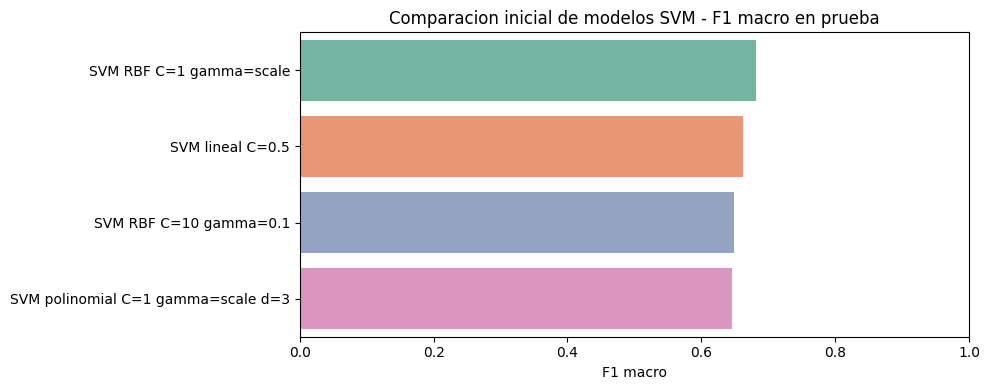

In [7]:
svm_configs = [
    {
        "modelo": "SVM lineal C=0.5",
        "kernel": "linear",
        "C": 0.5,
        "gamma": "scale",
        "degree": 3,
    },
    {
        "modelo": "SVM RBF C=1 gamma=scale",
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "degree": 3,
    },
    {
        "modelo": "SVM RBF C=10 gamma=0.1",
        "kernel": "rbf",
        "C": 10.0,
        "gamma": 0.1,
        "degree": 3,
    },
    {
        "modelo": "SVM polinomial C=1 gamma=scale d=3",
        "kernel": "poly",
        "C": 1.0,
        "gamma": "scale",
        "degree": 3,
    },
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
modelos_svm = {}
resultados_svm = []

for config in svm_configs:
    nombre = config["modelo"]
    modelo = SVC(
        kernel=config["kernel"],
        C=config["C"],
        gamma=config["gamma"],
        degree=config["degree"],
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )

    inicio_cv = time.perf_counter()
    cv_scores = cross_validate(
        modelo,
        X_train_svm,
        y_train_svm,
        cv=cv,
        scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
        n_jobs=-1,
    )
    tiempo_cv = time.perf_counter() - inicio_cv

    inicio_fit = time.perf_counter()
    modelo.fit(X_train_svm, y_train_svm)
    tiempo_fit = time.perf_counter() - inicio_fit

    y_pred_train = modelo.predict(X_train_svm)
    y_pred_test = modelo.predict(X_test_svm)

    fila = {
        "modelo": nombre,
        "kernel": config["kernel"],
        "C": config["C"],
        "gamma": config["gamma"],
        "d": config["degree"] if config["kernel"] == "poly" else np.nan,
        "cv_accuracy": cv_scores["test_accuracy"].mean(),
        "cv_f1_macro": cv_scores["test_f1_macro"].mean(),
        "train_accuracy": accuracy_score(y_train_svm, y_pred_train),
        "test_accuracy": accuracy_score(y_test_svm, y_pred_test),
        "test_f1_macro": f1_score(y_test_svm, y_pred_test, average="macro"),
        "tiempo_cv_seg": tiempo_cv,
        "tiempo_fit_seg": tiempo_fit,
    }
    resultados_svm.append(fila)
    modelos_svm[nombre] = modelo

resultados_svm_df = pd.DataFrame(resultados_svm).sort_values("test_f1_macro", ascending=False)
display(resultados_svm_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=resultados_svm_df, x="test_f1_macro", y="modelo", palette="Set2")
plt.title("Comparacion inicial de modelos SVM - F1 macro en prueba")
plt.xlabel("F1 macro")
plt.ylabel("")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## Lectura preliminar de resultados

Esta tabla sirve como punto de partida para los pasos siguientes del laboratorio. Para escoger el mejor SVM no conviene usar solo `accuracy`, porque las clases pueden tener errores con impacto distinto. `F1 macro` resume el desempeno por clase dando el mismo peso a `Economica`, `Intermedia` y `Cara`.

En los pasos siguientes se deben usar estos modelos para predecir, construir matrices de confusion, analizar sobreajuste/desajuste y compararlos contra modelos de laboratorios anteriores bajo el mismo split.

In [8]:
mejor_modelo_nombre = resultados_svm_df.iloc[0]["modelo"]
mejor_modelo_svm = modelos_svm[mejor_modelo_nombre]

print(f"Mejor modelo preliminar segun F1 macro en prueba: {mejor_modelo_nombre}")
print("Metricas del mejor modelo:")
display(resultados_svm_df.head(1).T)

Mejor modelo preliminar segun F1 macro en prueba: SVM RBF C=1 gamma=scale
Metricas del mejor modelo:


,1
modelo,SVM RBF C=1 gamma=scale
kernel,rbf
C,1.0000
gamma,scale
d,NaN
cv_accuracy,0.6784
cv_f1_macro,0.6792
train_accuracy,0.7354
test_accuracy,0.6817
test_f1_macro,0.6821
